# Step 6  
Input: s3://thesis--ec331-s3/capped-volume-bids/  
Output: s3://thesis--ec331-s3/capped-volume-bids/  

In [18]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.7 MB/s eta 0:00:008.8 MB/s eta 0:00:01


In [5]:
import pandas as pd
import boto3
from io import BytesIO

In [6]:
# Configure pandas display settings to show all rows and columns
pd.set_option('display.max_rows', 100)  # Show all 100 rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Use maximum width
pd.set_option('display.expand_frame_repr', False)  # Don't wrap to multiple lines

In [8]:
import pandas as pd
import s3fs

# Set up S3 filesystem
fs = s3fs.S3FileSystem()

# Path to your S3 bucket
s3_path = "s3://thesis--ec331-s3/merged-price-volume-bids/RAISE1SEC_PUBLIC_DVD_BIDPEROFFER2_202310010000_capped/"

# List all subdirectories in the main folder
subdirectories = fs.ls(s3_path)

# Initialize list to store dataframes
df_list = []

# Iterate through each subdirectory and find parquet files
for subdir in subdirectories:
    # Get all parquet files in this subdirectory
    parquet_files = [f for f in fs.ls(subdir) if f.endswith('.parquet')]
    
    print(f"Found {len(parquet_files)} parquet files in {subdir}")
    
    # Read each parquet file and add to the list
    for file in parquet_files:
        df = pd.read_parquet(f"s3://{file}")
        df_list.append(df)

# Combine all dataframes
if df_list:
    df_combined = pd.concat(df_list, ignore_index=True)
    print(f"Combined DataFrame shape: {df_combined.shape}")
    print(df_combined.head())
else:
    print("No parquet files found in any subdirectory")

Found 1 parquet files in thesis--ec331-s3/merged-price-volume-bids/RAISE1SEC_PUBLIC_DVD_BIDPEROFFER2_202310010000_capped/TRADINGDATE=2023-10-08 00:00:00
Found 2 parquet files in thesis--ec331-s3/merged-price-volume-bids/RAISE1SEC_PUBLIC_DVD_BIDPEROFFER2_202310010000_capped/TRADINGDATE=2023-10-09 00:00:00
Found 1 parquet files in thesis--ec331-s3/merged-price-volume-bids/RAISE1SEC_PUBLIC_DVD_BIDPEROFFER2_202310010000_capped/TRADINGDATE=2023-10-10 00:00:00
Found 2 parquet files in thesis--ec331-s3/merged-price-volume-bids/RAISE1SEC_PUBLIC_DVD_BIDPEROFFER2_202310010000_capped/TRADINGDATE=2023-10-11 00:00:00
Found 1 parquet files in thesis--ec331-s3/merged-price-volume-bids/RAISE1SEC_PUBLIC_DVD_BIDPEROFFER2_202310010000_capped/TRADINGDATE=2023-10-12 00:00:00
Found 2 parquet files in thesis--ec331-s3/merged-price-volume-bids/RAISE1SEC_PUBLIC_DVD_BIDPEROFFER2_202310010000_capped/TRADINGDATE=2023-10-13 00:00:00
Found 1 parquet files in thesis--ec331-s3/merged-price-volume-bids/RAISE1SEC_PUBLI

In [9]:
df_combined

,PERIODID,MAXAVAIL,DUID,BIDBAND,Participant,Station_Name,Region,Dispatch_Type,BIDVOLUME,BIDTYPE,SETTLEMENTDATE,PARTICIPANTID,BIDPRICE
0,1.0,0.0,ASNENC1,1,NaN,NaN,NaN,NaN,0.0,RAISE1SEC,2023-10-08,ENOCMASP,0.0
1,2.0,0.0,ASNENC1,1,NaN,NaN,NaN,NaN,0.0,RAISE1SEC,2023-10-08,ENOCMASP,0.0
2,3.0,0.0,ASNENC1,1,NaN,NaN,NaN,NaN,0.0,RAISE1SEC,2023-10-08,ENOCMASP,0.0
3,4.0,0.0,ASNENC1,1,NaN,NaN,NaN,NaN,0.0,RAISE1SEC,2023-10-08,ENOCMASP,0.0
4,5.0,0.0,ASNENC1,1,NaN,NaN,NaN,NaN,0.0,RAISE1SEC,2023-10-08,ENOCMASP,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
417595,252.0,4.0,DRVIOT05,10,NaN,NaN,NaN,NaN,1.0,RAISE1SEC,2023-10-15,VIOTAS,14990.0
417596,253.0,4.0,DRVIOT05,10,NaN,NaN,NaN,NaN,1.0,RAISE1SEC,2023-10-15,VIOTAS,14990.0
417597,254.0,4.0,DRVIOT05,10,NaN,NaN,NaN,NaN,1.0,RAISE1SEC,2023-10-15,VIOTAS,14990.0
417598,255.0,4.0,DRVIOT05,10,NaN,NaN,NaN,NaN,1.0,RAISE1SEC,2023-10-15,VIOTAS,14990.0


In [10]:
# Count rows where BIDVOLUME equals 0
zero_bid_volume_count = (df_combined['BIDVOLUME'] == 0).sum()

# Print the count and percentage of total rows
total_rows = len(df_combined)
percentage = (zero_bid_volume_count / total_rows) * 100

print(f"Number of rows where BIDVOLUME = 0: {zero_bid_volume_count}")
print(f"Percentage of total rows: {percentage:.2f}%")

Number of rows where BIDVOLUME = 0: 340235
Percentage of total rows: 81.47%


In [11]:
unique_DUIDS = df_combined['DUID'].unique()
len(unique_DUIDS)

19

Supply Bid Data for DRVIOT05 on 2023-10-15, Period 252:
        BIDBAND  BIDVOLUME  BIDPRICE  CUMULATIVE_VOLUME
386779        1        3.0      0.00                3.0
390203        2        0.0      0.95                3.0
393627        3        0.0      1.90                3.0
397051        4        0.0      3.80                3.0
400475        5        0.0      7.50                3.0
403899        6        0.0     14.90                3.0
407323        7        0.0     29.00                3.0
410747        8        0.0     98.00                3.0
414171        9        0.0    298.00                3.0
417595       10        1.0  14990.00                4.0


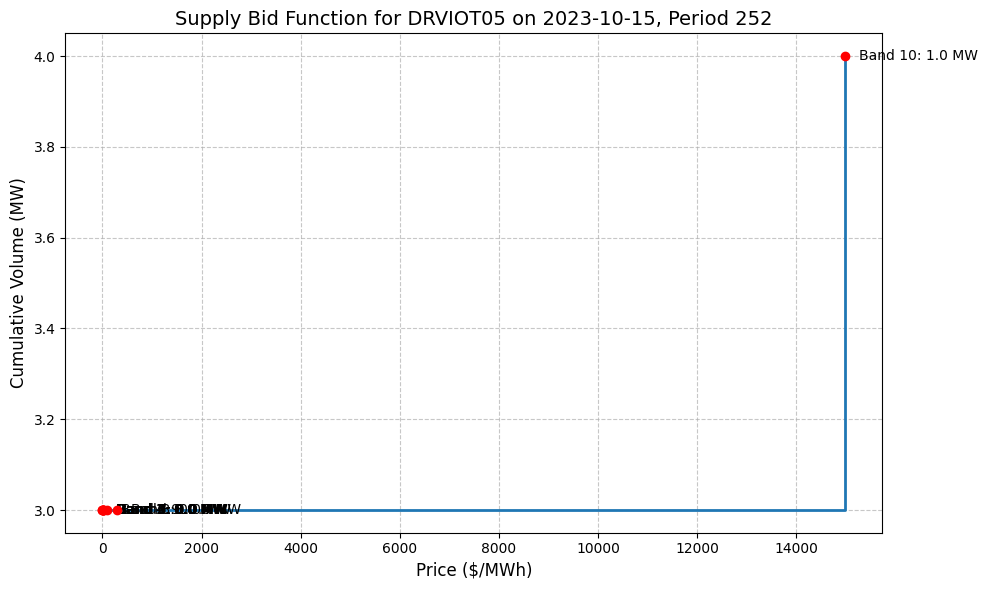

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter data for the specific tradingdate-periodid-duid combination
selected_bids = df_combined[
    (df_combined['SETTLEMENTDATE'] == '2023-10-15') & 
    (df_combined['PERIODID'] == 252) & 
    (df_combined['DUID'] == 'DRVIOT05')
].copy()

# Sort by BIDBAND to construct the supply curve properly
selected_bids = selected_bids.sort_values('BIDBAND')

# Create cumulative sum of volumes for the step function
selected_bids['CUMULATIVE_VOLUME'] = selected_bids['BIDVOLUME'].cumsum()

# Display the bid data
print("Supply Bid Data for DRVIOT05 on 2023-10-15, Period 252:")
print(selected_bids[['BIDBAND', 'BIDVOLUME', 'BIDPRICE', 'CUMULATIVE_VOLUME']])

# Plot the supply bid function
plt.figure(figsize=(10, 6))
plt.step(selected_bids['BIDPRICE'], selected_bids['CUMULATIVE_VOLUME'], where='post', linewidth=2)
plt.scatter(selected_bids['BIDPRICE'], selected_bids['CUMULATIVE_VOLUME'], color='red', zorder=5)

plt.title('Supply Bid Function for DRVIOT05 on 2023-10-15, Period 252', fontsize=14)
plt.xlabel('Price ($/MWh)', fontsize=12)
plt.ylabel('Cumulative Volume (MW)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Add annotations for each bid band
for i, row in selected_bids.iterrows():
    plt.annotate(f"Band {int(row['BIDBAND'])}: {row['BIDVOLUME']} MW", 
                 xy=(row['BIDPRICE'], row['CUMULATIVE_VOLUME']),
                 xytext=(10, 0), textcoords='offset points',
                 ha='left', va='center')

plt.tight_layout()
plt.savefig('supply_bid_function.png')
plt.show()

In [14]:
df_combined.describe()

,PERIODID,MAXAVAIL,BIDBAND,BIDVOLUME,SETTLEMENTDATE,BIDPRICE
count,417600.000000,417600.000000,417600.000000,417600.000000,417600,417600.000000
mean,144.500000,10.186088,5.500000,1.018609,2023-10-11 11:35:10.344827392,1507.097168
min,1.000000,0.000000,1.000000,0.000000,2023-10-08 00:00:00,0.000000
25%,72.750000,0.000000,3.000000,0.000000,2023-10-09 00:00:00,1.900000
50%,144.500000,1.000000,5.500000,0.000000,2023-10-11 00:00:00,15.500000
75%,216.250000,12.000000,8.000000,0.000000,2023-10-13 00:00:00,98.000000
max,288.000000,171.000000,10.000000,145.000000,2023-10-15 00:00:00,16600.000000
std,83.138037,19.309427,2.872285,4.918690,NaN,4487.931641


In [15]:
# Filter data for DRVIOT05
drviot05_data = df_combined[df_combined['DUID'] == 'DRVIOT05'].copy()

# Check how many rows we have
print(f"Found {len(drviot05_data)} bids for DRVIOT05")

# Remove any rows with zero volume to avoid skewing calculations
drviot05_data = drviot05_data[drviot05_data['BIDVOLUME'] > 0]
print(f"After removing zero volume bids: {len(drviot05_data)} rows")

# Calculate volume-weighted average price across entire time period
total_volume = drviot05_data['BIDVOLUME'].sum()
weighted_avg_price = (drviot05_data['BIDPRICE'] * drviot05_data['BIDVOLUME']).sum() / total_volume

# Calculate standard deviation (weighted)
variance = np.average((drviot05_data['BIDPRICE'] - weighted_avg_price)**2, 
                      weights=drviot05_data['BIDVOLUME'])
weighted_std_dev = np.sqrt(variance)

print(f"\nSummary statistics for DRVIOT05 across all time periods:")
print(f"Total Volume Offered: {total_volume:.2f} MW")
print(f"Volume-Weighted Average Price: ${weighted_avg_price:.2f}/MWh")
print(f"Volume-Weighted Price Standard Deviation: ${weighted_std_dev:.2f}/MWh")

# Optional: Show some additional statistics
print("\nAdditional Statistics:")
print(f"Date Range: {drviot05_data['SETTLEMENTDATE'].min()} to {drviot05_data['SETTLEMENTDATE'].max()}")
print(f"Number of unique Trading Dates: {drviot05_data['SETTLEMENTDATE'].nunique()}")
print(f"Number of unique Period IDs: {drviot05_data['PERIODID'].nunique()}")
print(f"Number of unique Bid Bands used: {drviot05_data['BIDBAND'].nunique()}")
print(f"Price Range: ${drviot05_data['BIDPRICE'].min():.2f} to ${drviot05_data['BIDPRICE'].max():.2f}/MWh")

Found 23040 bids for DRVIOT05
After removing zero volume bids: 3772 rows

Summary statistics for DRVIOT05 across all time periods:
Total Volume Offered: 7349.00 MW
Volume-Weighted Average Price: $4895.36/MWh
Volume-Weighted Price Standard Deviation: $7029.72/MWh

Additional Statistics:
Date Range: 2023-10-09 00:00:00 to 2023-10-15 00:00:00
Number of unique Trading Dates: 7
Number of unique Period IDs: 288
Number of unique Bid Bands used: 2
Price Range: $0.00 to $14990.00/MWh


In [16]:
# Group by date and calculate daily weighted average prices
daily_stats = drviot05_data.groupby('SETTLEMENTDATE').apply(
    lambda x: pd.Series({
        'total_volume': x['BIDVOLUME'].sum(),
        'weighted_avg_price': (x['BIDPRICE'] * x['BIDVOLUME']).sum() / x['BIDVOLUME'].sum(),
        'num_bids': len(x)
    })
).reset_index()

print("\nSample of daily statistics:")
print(daily_stats.head())


Sample of daily statistics:
  SETTLEMENTDATE  total_volume  weighted_avg_price  num_bids
0     2023-10-09        1152.0         3747.500000     576.0
1     2023-10-10        1143.0         3763.893311     572.0
2     2023-10-11        1140.0         3944.736816     576.0
3     2023-10-12        1007.0         6445.551270     576.0
4     2023-10-13        1011.0         5426.646973     519.0


/tmp/ipykernel_9017/1598916161.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_stats = drviot05_data.groupby('SETTLEMENTDATE').apply(


/tmp/ipykernel_9017/3367483302.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_stats = drviot05_data.groupby('SETTLEMENTDATE').apply(


Summary statistics for DRVIOT05:
Date Range: 2023-10-09 00:00:00 to 2023-10-15 00:00:00
Total Volume Offered: 7349.00 MW
Volume-Weighted Average Price: $4895.36/MWh
Volume-Weighted Price Standard Deviation: $7029.72/MWh
Number of unique Trading Dates: 7
Number of unique Bid Bands used: 2
Price Range: $0.00 to $14990.00/MWh


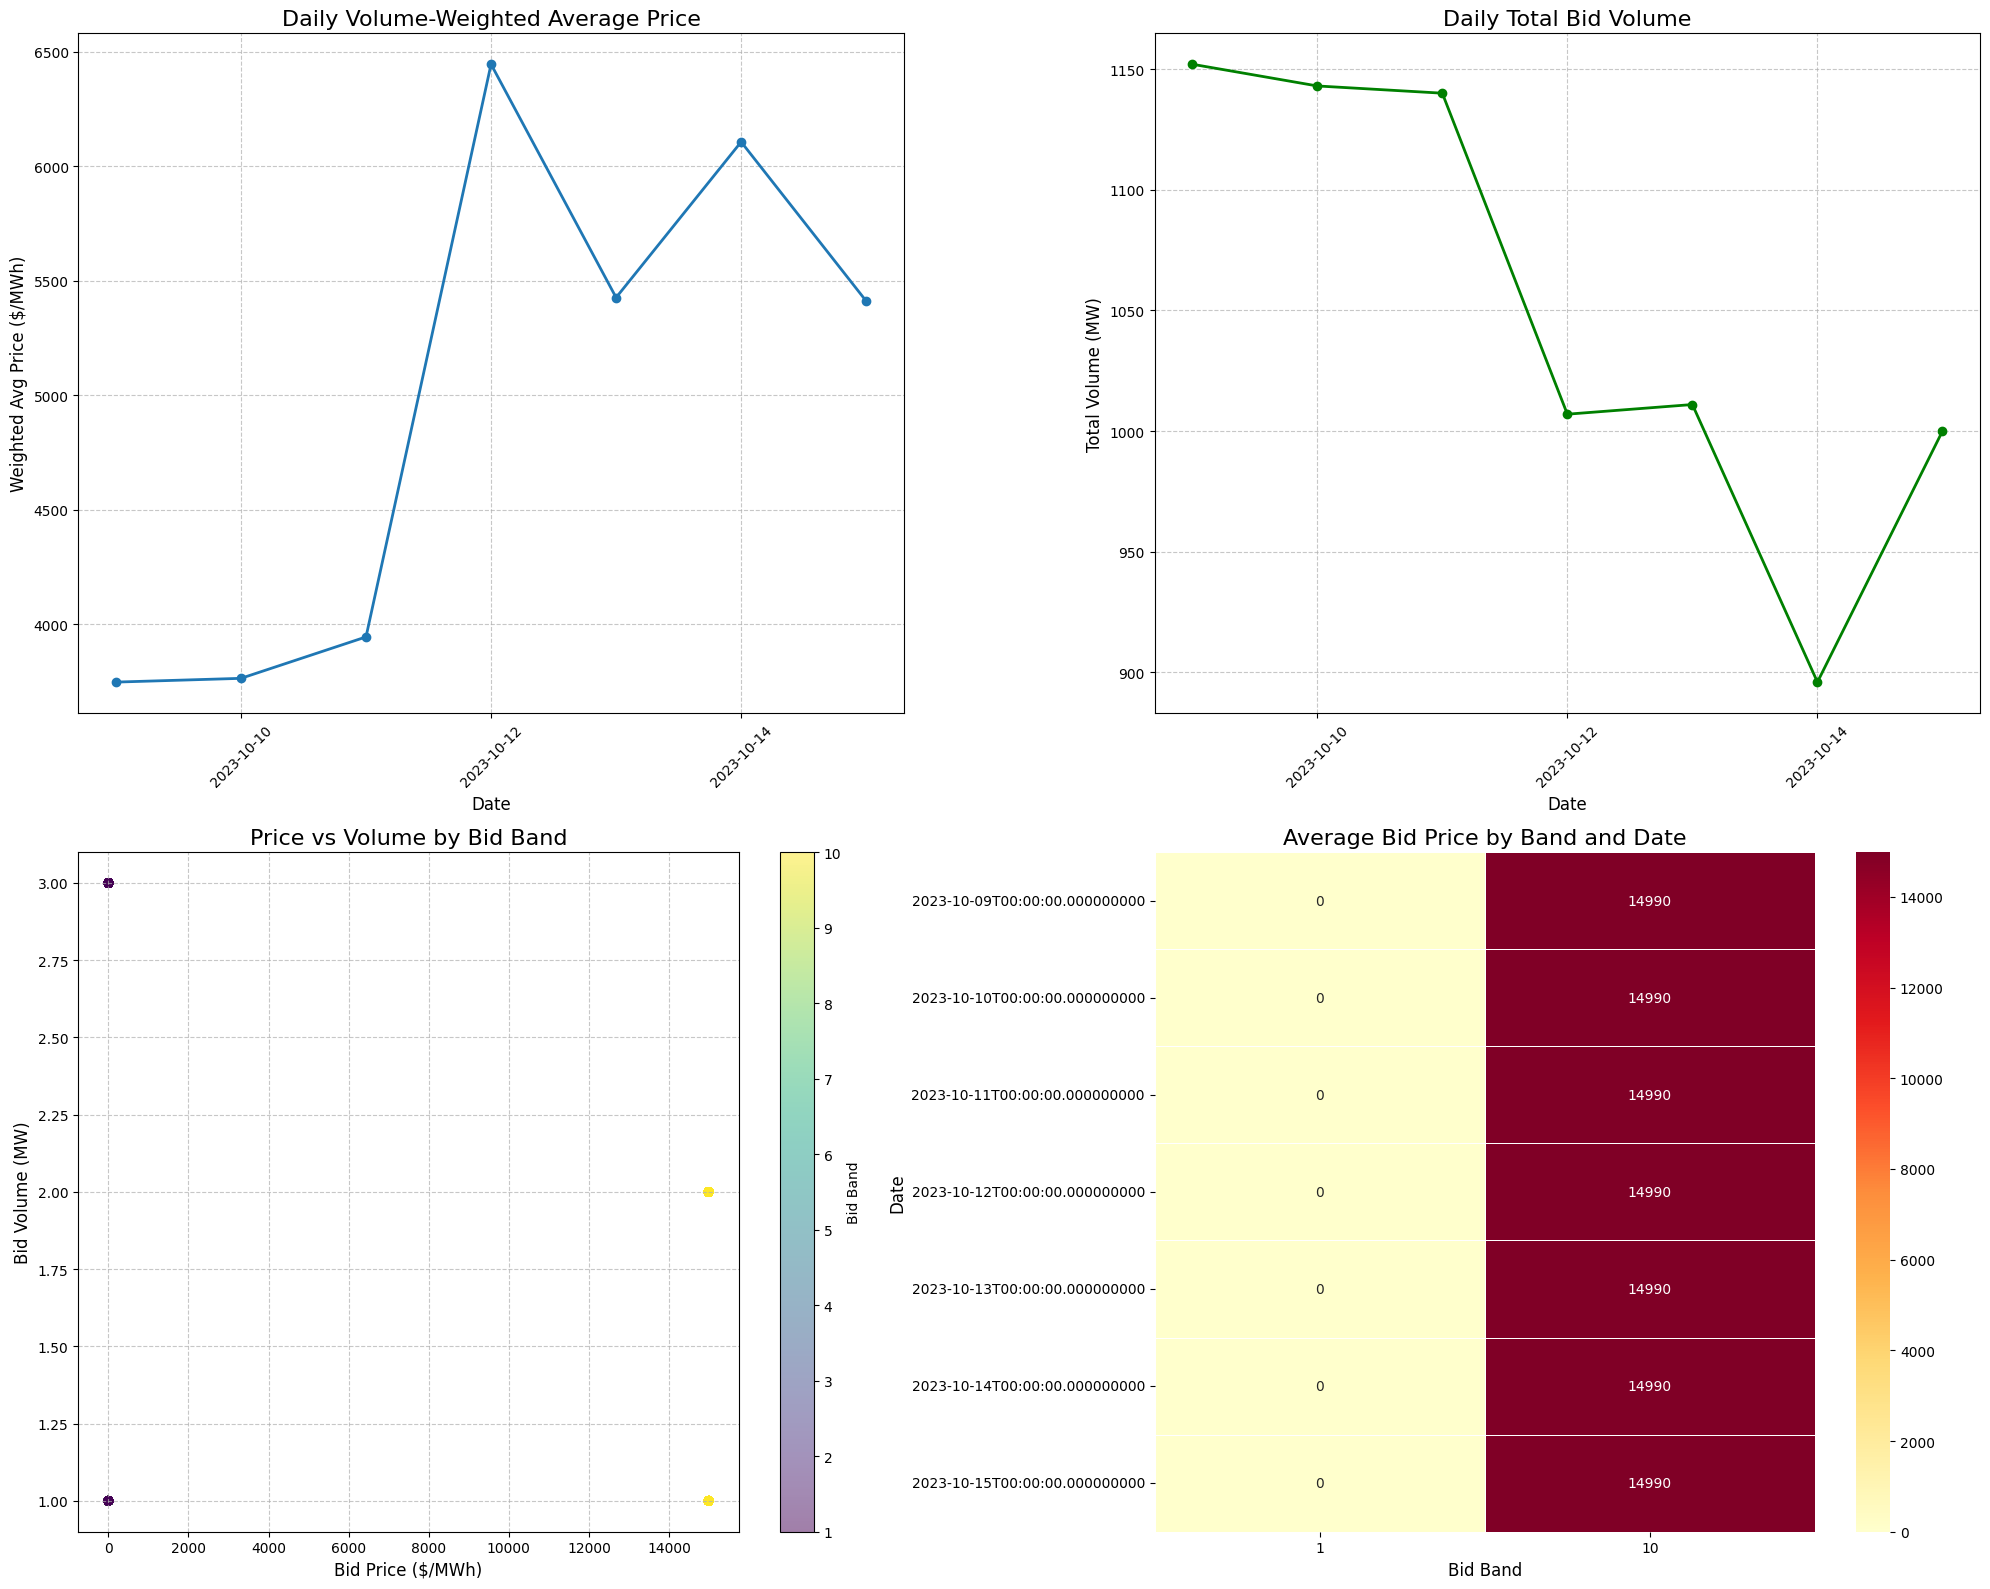

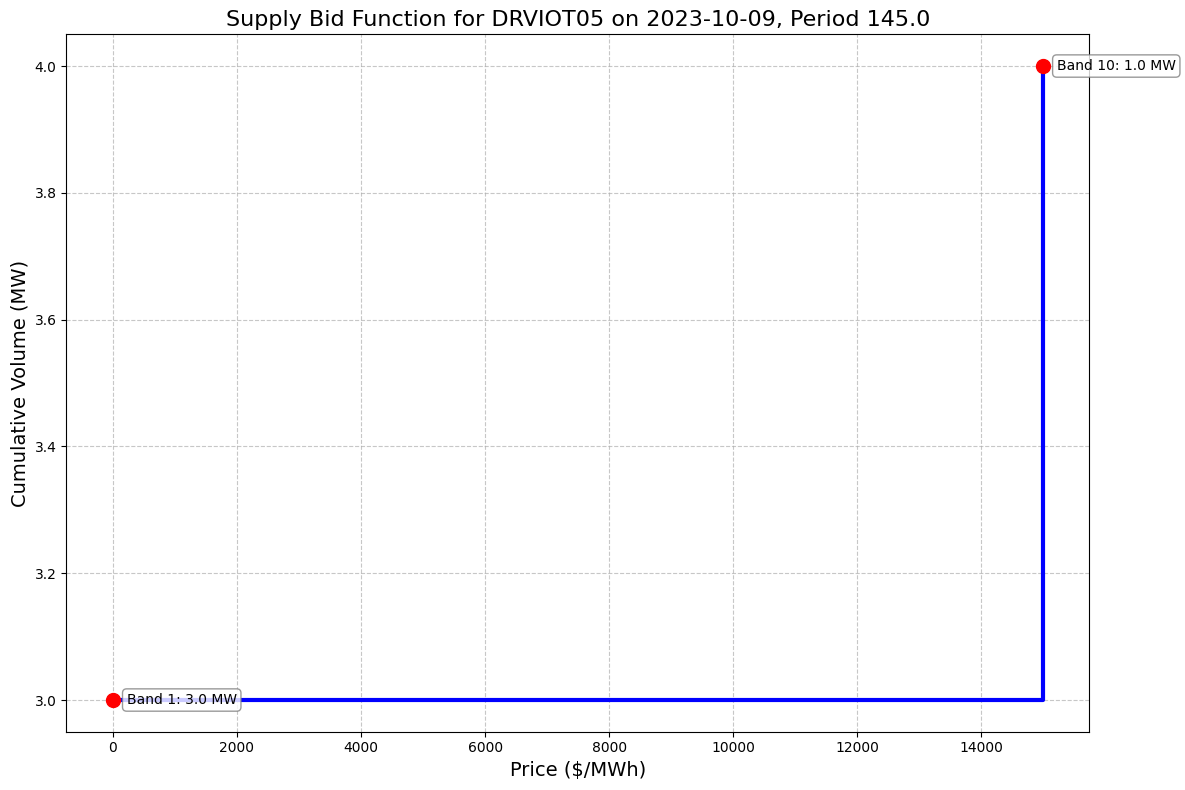

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

# Assuming df_combined is your dataframe with all the bid data
# Filter data for DRVIOT05
drviot05_data = df_combined[df_combined['DUID'] == 'DRVIOT05'].copy()

# Remove any rows with zero volume
drviot05_data = drviot05_data[drviot05_data['BIDVOLUME'] > 0]

# Ensure SETTLEMENTDATE is datetime
if drviot05_data['SETTLEMENTDATE'].dtype != 'datetime64[ns]':
    drviot05_data['SETTLEMENTDATE'] = pd.to_datetime(drviot05_data['SETTLEMENTDATE'])

# Group by date and calculate daily weighted average prices
daily_stats = drviot05_data.groupby('SETTLEMENTDATE').apply(
    lambda x: pd.Series({
        'total_volume': x['BIDVOLUME'].sum(),
        'weighted_avg_price': (x['BIDPRICE'] * x['BIDVOLUME']).sum() / x['BIDVOLUME'].sum(),
        'num_bids': len(x),
        'std_dev': np.sqrt(np.average((x['BIDPRICE'] - 
                           ((x['BIDPRICE'] * x['BIDVOLUME']).sum() / x['BIDVOLUME'].sum()))**2, 
                           weights=x['BIDVOLUME'])) if len(x) > 1 else 0
    })
).reset_index()

# Create a figure with multiple subplots
plt.figure(figsize=(20, 16))

# 1. Time series of weighted average price
plt.subplot(2, 2, 1)
plt.plot(daily_stats['SETTLEMENTDATE'], daily_stats['weighted_avg_price'], 'o-', linewidth=2)
plt.title('Daily Volume-Weighted Average Price', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weighted Avg Price ($/MWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

# 2. Time series of total daily volume
plt.subplot(2, 2, 2)
plt.plot(daily_stats['SETTLEMENTDATE'], daily_stats['total_volume'], 'o-', color='green', linewidth=2)
plt.title('Daily Total Bid Volume', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Volume (MW)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

# 3. Price vs Volume scatter plot
plt.subplot(2, 2, 3)
plt.scatter(drviot05_data['BIDPRICE'], drviot05_data['BIDVOLUME'], 
            alpha=0.5, c=drviot05_data['BIDBAND'], cmap='viridis')
plt.colorbar(label='Bid Band')
plt.title('Price vs Volume by Bid Band', fontsize=16)
plt.xlabel('Bid Price ($/MWh)', fontsize=12)
plt.ylabel('Bid Volume (MW)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Heatmap of bid prices across bands and days
# First, need to pivot data to create a matrix suitable for heatmap
# Sample a few days for clarity if there are too many days
if drviot05_data['SETTLEMENTDATE'].nunique() > 10:
    sampled_dates = sorted(drviot05_data['SETTLEMENTDATE'].unique())[-10:]  # Last 10 days
    heatmap_data = drviot05_data[drviot05_data['SETTLEMENTDATE'].isin(sampled_dates)]
else:
    heatmap_data = drviot05_data

# Group by date and bid band, getting average price
heatmap_pivot = heatmap_data.groupby(['SETTLEMENTDATE', 'BIDBAND'])['BIDPRICE'].mean().unstack()

plt.subplot(2, 2, 4)
sns.heatmap(heatmap_pivot, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=.5)
plt.title('Average Bid Price by Band and Date', fontsize=16)
plt.xlabel('Bid Band', fontsize=12)
plt.ylabel('Date', fontsize=12)

plt.tight_layout()
plt.savefig('drviot05_bid_analysis.png', dpi=300, bbox_inches='tight')

# Create an additional figure with bid function for a selected day
# Find the day with the most bids for a representative example
representative_date = drviot05_data.groupby('SETTLEMENTDATE').size().idxmax()

plt.figure(figsize=(12, 8))
representative_data = drviot05_data[drviot05_data['SETTLEMENTDATE'] == representative_date].copy()
representative_data = representative_data.sort_values('BIDBAND')

# Select a representative period ID (e.g., middle of the day)
if 'PERIODID' in representative_data.columns:
    period_ids = sorted(representative_data['PERIODID'].unique())
    selected_period = period_ids[len(period_ids)//2]  # Middle period
    representative_data = representative_data[representative_data['PERIODID'] == selected_period]

# Create supply curve
representative_data = representative_data.sort_values('BIDPRICE')
representative_data['CUMULATIVE_VOLUME'] = representative_data['BIDVOLUME'].cumsum()

plt.step(representative_data['BIDPRICE'], representative_data['CUMULATIVE_VOLUME'], 
         where='post', linewidth=3, color='blue')
plt.scatter(representative_data['BIDPRICE'], representative_data['CUMULATIVE_VOLUME'], 
            color='red', s=100, zorder=5)

# Add annotations for each bid band
for i, row in representative_data.iterrows():
    plt.annotate(f"Band {int(row['BIDBAND'])}: {row['BIDVOLUME']} MW", 
                 xy=(row['BIDPRICE'], row['CUMULATIVE_VOLUME']),
                 xytext=(10, 0), textcoords='offset points',
                 ha='left', va='center', fontsize=10, 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.savefig('drviot05_supply_function.png', dpi=300, bbox_inches='tight')

# Calculate summary statistics for the entire period
total_volume = drviot05_data['BIDVOLUME'].sum()
weighted_avg_price = (drviot05_data['BIDPRICE'] * drviot05_data['BIDVOLUME']).sum() / total_volume

if len(drviot05_data) > 1:
    variance = np.average((drviot05_data['BIDPRICE'] - weighted_avg_price)**2, 
                        weights=drviot05_data['BIDVOLUME'])
    weighted_std_dev = np.sqrt(variance)
else:
    weighted_std_dev = 0

print(f"Summary statistics for DRVIOT05:")
print(f"Date Range: {drviot05_data['SETTLEMENTDATE'].min()} to {drviot05_data['SETTLEMENTDATE'].max()}")
print(f"Total Volume Offered: {total_volume:.2f} MW")
print(f"Volume-Weighted Average Price: ${weighted_avg_price:.2f}/MWh")
print(f"Volume-Weighted Price Standard Deviation: ${weighted_std_dev:.2f}/MWh")
print(f"Number of unique Trading Dates: {drviot05_data['SETTLEMENTDATE'].nunique()}")
print(f"Number of unique Bid Bands used: {drviot05_data['BIDBAND'].nunique()}")
print(f"Price Range: ${drviot05_data['BIDPRICE'].min():.2f} to ${drviot05_data['BIDPRICE'].max():.2f}/MWh")

In [21]:
# Group by DUID, SETTLEMENTDATE, and PERIODID, then calculate volume-weighted average price
vwap_df = df_combined.groupby(['DUID', 'SETTLEMENTDATE', 'PERIODID']).apply(
    lambda x: pd.Series({
        'weighted_avg_price': (x['BIDPRICE'] * x['BIDVOLUME']).sum() / x['BIDVOLUME'].sum() 
                              if x['BIDVOLUME'].sum() > 0 else np.nan,
        'total_volume_bid': x['BIDVOLUME'].sum(),
        'min_price': x['BIDPRICE'].min(),
        'max_price': x['BIDPRICE'].max(),
    })
).reset_index()

# Handle any cases where total volume is zero (would result in NaN for weighted_avg_price)
vwap_df = vwap_df.dropna(subset=['weighted_avg_price'])

# Print the shape and a sample of the new dataframe
print(f"VWAP DataFrame shape: {vwap_df.shape}")
print("\nSample of VWAP DataFrame:")
print(vwap_df.head(10))

# Optional: Summary statistics
print("\nSummary Statistics:")
print(vwap_df['weighted_avg_price'].describe())

# Optional: Save to CSV if needed
# vwap_df.to_csv('volume_weighted_avg_prices.csv', index=False)

VWAP DataFrame shape: (29774, 7)

Sample of VWAP DataFrame:
        DUID SETTLEMENTDATE  PERIODID  weighted_avg_price  total_volume_bid  min_price  max_price
288  ASNENC1     2023-10-09       1.0               256.0              30.0        0.0      256.0
289  ASNENC1     2023-10-09       2.0               256.0              30.0        0.0      256.0
290  ASNENC1     2023-10-09       3.0               256.0              30.0        0.0      256.0
291  ASNENC1     2023-10-09       4.0               256.0              30.0        0.0      256.0
292  ASNENC1     2023-10-09       5.0               256.0              30.0        0.0      256.0
293  ASNENC1     2023-10-09       6.0               256.0              30.0        0.0      256.0
294  ASNENC1     2023-10-09       7.0               256.0              30.0        0.0      256.0
295  ASNENC1     2023-10-09       8.0               256.0              30.0        0.0      256.0
296  ASNENC1     2023-10-09       9.0               256.0 

/tmp/ipykernel_9017/1717863755.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vwap_df = df_combined.groupby(['DUID', 'SETTLEMENTDATE', 'PERIODID']).apply(
